# Vectorized QMC (Bayesian)

Demonstrates Bayesian cubature rules (`CubQMCBayesLatticeG` and `CubQMCBayesNetG`) for integration, which model the integrand as a Gaussian process and provide posterior credible intervals as error estimates.

Original QMCPy demo: [`QMCPy/demos/vectorized_qmc_bayes.ipynb`](../../QMCPy/demos/vectorized_qmc_bayes.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QuasiMC.jl/blob/develop/demos/vectorized_qmc_bayes.ipynb)

*This Julia notebook keeps the QMCPy `LD Sequence`, `Simple Example`, and Bayesian logistic-regression structure, then adds Bayesian cubature features with direct `QuasiMC.jl` support.*

Parity note: this Julia notebook keeps the QMCPy `LD Sequence`, `Simple Example`, and Bayesian logistic-regression structure, and labels the later Bayesian-cubature comparison sections as Julia extensions. The logistic-regression calculation uses a Laplace-centered QMC proposal to avoid underflow in the direct prior-sampling ratio estimator.


In [1]:
using QuasiMC
using LinearAlgebra: Diagonal
import QuasiMC: Uniform
using Statistics
using Printf

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## LD Sequence

Compare IID, digital net, and lattice point sets.

In [2]:
n = 2^6
for (dd, name) in [
    (IIDStdUniform(2; seed=7),  "IID"),
    (DigitalNetB2(2; seed=7),   "Digital Net"),
    (Lattice(2; seed=7),        "Lattice"),
]
    pts = gen_samples(dd, n)
    println("$name ($n points):")
    println("  Mean:  $(round.(mean(pts, dims=1), digits=3))")
    println("  Range: [$(round.(minimum(pts, dims=1), digits=3)), " *
            "$(round.(maximum(pts, dims=1), digits=3))]")
end

IID (64 points):
  Mean:  [0.506 0.422]
  Range: [[0.0 0.027], [0.988 0.977]]
Digital Net (64 points):
  Mean:  [0.497 0.503]
  Range: [[0.004 0.011], [0.989 0.995]]
Lattice (64 points):
  Mean:  [0.507 0.499]
  Range: [[0.015 0.007], [0.999 0.991]]


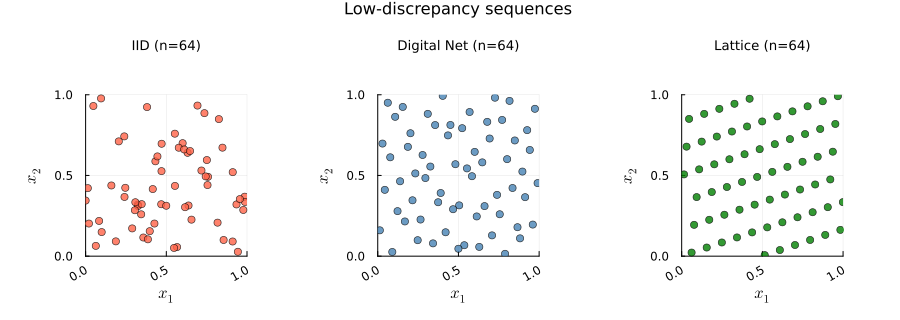

In [3]:
if HAVE_PLOTS
    n_s = 2^6
    sampler_specs = [
        ("IID",         IIDStdUniform(2; seed=7),  :tomato),
        ("Digital Net", DigitalNetB2(2; seed=7, t=63),   :steelblue),
        ("Lattice",     Lattice(2; seed=7),         :green),
    ]
    scatter_plts = []
    for (name, dd, col) in sampler_specs
        pts = gen_samples(dd, n_s)
        subplot = scatter(pts[:, 1], pts[:, 2];
            markersize=4, alpha=0.8, color=col, label=nothing,
            xlabel="\$x_1\$", ylabel="\$x_2\$",
            title="$name (n=$n_s)",
            xlims=(0, 1), ylims=(0, 1), aspect_ratio=:equal,
            xticks=[0, 0.5, 1], yticks=[0, 0.5, 1], xrotation=30,
            left_margin=2Plots.mm, right_margin=2Plots.mm)
        push!(scatter_plts, subplot)
    end
    display(plot(scatter_plts...; layout=(1, 3), size=(900, 320),
        plot_titlevspan=0.12, plot_title="Low-discrepancy sequences",
        top_margin=10Plots.mm, bottom_margin=8Plots.mm))
end


## Simple Example

3D input → 2D output: displacement D and stress S as functions of Young's modulus E, horizontal load X, and vertical load Y.

In [4]:
function cantilever_beam(x)
    l, w, t = 100.0, 4.0, 2.0
    E, X, Y = x[1], x[2], x[3]
    D = 4l^3 / (E * w * t) * sqrt(X^2/t^4 + Y^2/w^4)
    S = 600 * (X / (w * t^2) + Y / (w^2 * t))
    return D, S
end

# Evaluate over points using the same Gaussian input model as QMCPy
dd = DigitalNetB2(3; seed=7, graycode=false)
tm_beam = Gaussian(dd;
    mean=[2.9e7, 500.0, 1000.0],
    covariance=Diagonal([(1.45e6)^2, (100.0)^2, (100.0)^2]))
u = gen_samples(dd, 1024)
x = transform(tm_beam, u)
D_vals = Float64[]
S_vals = Float64[]
for i in 1:size(x, 1)
    disp, stress = cantilever_beam(x[i, :])
    push!(D_vals, disp)
    push!(S_vals, stress)
end

display_table(
    [(quantity="Displacement D", mean=mean(D_vals), std=std(D_vals)),
     (quantity="Stress S",       mean=mean(S_vals), std=std(S_vals))];
    headers=["quantity", "mean", "std"],
    formatters=(
        mean=v -> @sprintf("%.4f", v),
        std=v -> @sprintf("%.4f", v)))

quantity,mean,std
Displacement D,2.4250,0.4047
Stress S,37489.9412,4194.3089


## BO QEI

The QMCPy Bayesian vectorized notebook routes through batched Bayesian-optimization material here. In QuasiMC.jl that material is handled in [`qei_demo.ipynb`](qei_demo.ipynb).


## Bayesian Logistic Regression

The same Haberman data, split, seed, and $N(0,5I)$ prior are used here. The posterior mean is evaluated with a Laplace-centered digital-net importance sampler, which retains the Bayesian target while avoiding numerical underflow from direct diffuse-prior sampling.


In [5]:
include(joinpath(@__DIR__, "data", "bayesian_lr_demo.jl"))
blr_result = bayesian_lr_demo()
feature_names = ["Age", "Operation year", "Axillary nodes", "Intercept"]
println("Bayesian posterior-mean coefficients:")
for (name, coefficient) in zip(feature_names, blr_result.coefficients)
    @printf("  %-15s % .6f\n", name, coefficient)
end
@printf("Test accuracy: %.1f%%\n", 100blr_result.accuracy)
@printf("Importance-sampling ESS: %.0f of %d points\n", blr_result.effective_sample_size, 2^16)
@assert all(isfinite, blr_result.coefficients)
@assert blr_result.accuracy > 0.65
@assert blr_result.effective_sample_size > 0.5 * 2^16


Bayesian posterior-mean coefficients:
  Age             -0.013232
  Operation year   0.020355
  Axillary nodes  -0.119728
  Intercept        0.968103
Test accuracy: 74.3%
Importance-sampling ESS: 62491 of 65536 points


## Sensitivity Indices

The Ishigami and machine-learning sensitivity sections from QMCPy are split into separate Julia demos rather than mixed into the Bayesian cubature notebook.


### Ishigami Function

See [`sensitivity_indices.ipynb`](sensitivity_indices.ipynb) for the direct Julia Ishigami sensitivity example.


### Neural Network

Related Julia-native machine-learning sensitivity material is maintained in [`iris.ipynb`](iris.ipynb), using `DecisionTree.jl` in place of scikit-learn while preserving the feature-sensitivity objective.


**Julia extension: Bayesian QMC Integration.**

Use the Bayesian stopping criteria which model the integrand as a sample path from a Gaussian process to obtain credible-interval-based error bounds.


In [6]:
# --- Bayesian Lattice ---
println("=== CubQMCBayesLatticeG ===")
let
    rows = NamedTuple{(:d, :solution, :error, :n)}[]
    for dim in [1, 3, 5]
        dd_lattice = Lattice(dim; seed=7)
        tm_lattice = Gaussian(dd_lattice; mean=0.0, covariance=0.5)
        f_lattice = Keister(tm_lattice)
        sc_lattice = CubQMCBayesLatticeG(f_lattice; abs_tol=1e-3)
        result_lattice = integrate(sc_lattice)
        exact_lattice = keister_exact(dim)
        err = abs(result_lattice.solution - exact_lattice)
        push!(rows, (d=dim, solution=result_lattice.solution, error=err, n=result_lattice.data[:n]))
    end
    display_table(rows;
        headers=["d", "solution", "error", "n"],
        formatters=(
            solution=v -> @sprintf("%.3f", v),
            error=v -> @sprintf("%.2e", v)))
end

=== CubQMCBayesLatticeG ===


d,solution,error,n
1,1.380,2.41e-08,256
3,2.167,9.36e-04,256
5,0.998,1.38e-01,256


In [7]:
# --- Bayesian Digital Net ---
println("=== CubQMCBayesNetG ===")
let
    rows = NamedTuple{(:d, :solution, :error, :n)}[]
    for dim in [1, 3, 5]
        dd_net = DigitalNetB2(dim; seed=7)
        tm_net = Gaussian(dd_net; mean=0.0, covariance=0.5)
        f_net = Keister(tm_net)
        sc_net = CubQMCBayesNetG(f_net; abs_tol=1e-3)
        result_net = integrate(sc_net)
        exact_net = keister_exact(dim)
        err = abs(result_net.solution - exact_net)
        push!(rows, (d=dim, solution=result_net.solution, error=err, n=result_net.data[:n]))
    end
    display_table(rows;
        headers=["d", "solution", "error", "n"],
        formatters=(
            solution=v -> @sprintf("%.3f", v),
            error=v -> @sprintf("%.2e", v)))
end

=== CubQMCBayesNetG ===


d,solution,error,n
1,1.380,6.34e-05,256
3,2.171,2.62e-03,512
5,1.158,2.24e-02,8192


**Julia extension: Comparison: Bayesian vs Frequentist QuasiMC.**

Compare the Bayesian stopping criteria with their frequentist counterparts (`CubQMCLatticeG`, `CubQMCNetG`) for the same tolerance.

This comparison is a Julia extension added to make the Bayesian-versus-frequentist contrast explicit in `QuasiMC.jl`.


In [8]:
d = 3
tol = 1e-3
exact = keister_exact(d)

println("Keister integral (d=$d), abs_tol=$tol\n")

let
    rows = NamedTuple{(:method, :solution, :error, :n)}[]
    for (name, make_sc) in [
        ("CubQMCLatticeG",      () -> begin
            dd_cmp = Lattice(d; seed=7)
            tm_cmp = Gaussian(dd_cmp; mean=0.0, covariance=0.5)
            CubQMCLatticeG(Keister(tm_cmp); abs_tol=tol)
        end),
        ("CubQMCBayesLatticeG", () -> begin
            dd_cmp = Lattice(d; seed=7)
            tm_cmp = Gaussian(dd_cmp; mean=0.0, covariance=0.5)
            CubQMCBayesLatticeG(Keister(tm_cmp); abs_tol=tol)
        end),
        ("CubQMCNetG",          () -> begin
            dd_cmp = DigitalNetB2(d; seed=7, randomize="LMS_DS", graycode=false)
            tm_cmp = Gaussian(dd_cmp; mean=0.0, covariance=0.5)
            CubQMCNetG(Keister(tm_cmp); abs_tol=tol)
        end),
        ("CubQMCBayesNetG",     () -> begin
            dd_cmp = DigitalNetB2(d; seed=7)
            tm_cmp = Gaussian(dd_cmp; mean=0.0, covariance=0.5)
            CubQMCBayesNetG(Keister(tm_cmp); abs_tol=tol)
        end),
    ]
        sc_cmp = make_sc()
        result_cmp = integrate(sc_cmp)
        err = abs(result_cmp.solution - exact)
        push!(rows, (method=name, solution=result_cmp.solution, error=err, n=result_cmp.data[:n]))
    end
    display_table(rows;
        headers=["method", "solution", "error", "n"],
        formatters=(
            solution=v -> @sprintf("%.3f", v),
            error=v -> @sprintf("%.2e", v)))
end

Keister integral (d=3), abs_tol=0.001



method,solution,error,n
CubQMCLatticeG,2.168,7.78e-06,16384
CubQMCBayesLatticeG,2.167,9.36e-04,256
CubQMCNetG,2.169,2.45e-04,16384
CubQMCBayesNetG,2.171,2.62e-03,512


**Julia extension: Convergence Comparison.**

This final section is another Julia extension that complements the shared QMCPy material with a direct convergence summary.


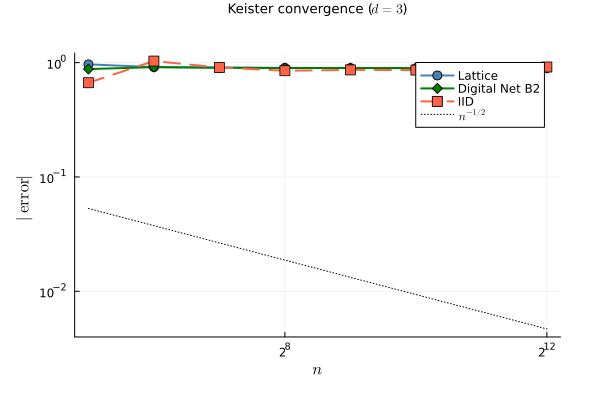

In [9]:
if HAVE_PLOTS
    # Keister convergence: Bayesian vs frequentist, lattice vs digital net
    d_c, tol_c = 3, 1e-3
    exact_c = keister_exact(d_c)
    ns_c = [2^k for k in 5:12]

    function keister_err(make_dd)
        [abs(mean(evaluate(Keister(Gaussian(make_dd(seed),
            mean=0.0, covariance=0.5)), gen_samples(make_dd(seed), n))) - exact_c)
         for (seed, n) in zip(1:length(ns_c), ns_c)]
    end

    err_lat  = keister_err(s -> Lattice(d_c; seed=s))
    err_net  = keister_err(s -> DigitalNetB2(d_c; seed=s, graycode=false))
    err_iid  = keister_err(s -> IIDStdUniform(d_c; seed=s))

    p = plot(ns_c, err_lat;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=5, color=:steelblue,
        label="Lattice",
        xlabel="\$n\$", ylabel="\$|\\mathrm{error}|\$",
        title="Keister convergence (\$d=$d_c\$)")
    plot!(ns_c, err_net; marker=:diamond, lw=2, ms=5, color=:green, label="Digital Net B2")
    plot!(ns_c, err_iid; marker=:square, lw=2, ms=5, color=:tomato, linestyle=:dash, label="IID")
    ref = Float64.(ns_c)
    plot!(ref, 0.3 .* ref .^ (-0.5); lw=1, color=:black, linestyle=:dot, label="\$n^{-1/2}\$")
    display(p)
end